In [9]:
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC

In [ ]:
data = load_breast_cancer()
# carrega dataset de cancer

In [ ]:
x,y = data['data'],data['target']
# separando as features caracteristicas e o target

In [ ]:
data['target_names']
# a classificação sera benigno e maligno

array(['malignant', 'benign'], dtype='<U9')

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)
# separação dos dados 80% para treino e 20% para teste

In [ ]:
clf = LinearSVC()
# instancia o modelo
clf.fit(x_train,y_train)
# treinando o modelo

LinearSVC()

In [ ]:
clf.score(x_test,y_test)
# como o modelo foi predizendo os dados de teste

0.9736842105263158

In [ ]:
clf.predict([x_train[1]])
# predição

array([0])

In [ ]:
explainer = shap.KernelExplainer(clf.predict,shap.kmeans(x_train,10))
# pega a predição do modelo e utilizanado o kmeans com 10 pontos medios da distribuição dos dados de treino

In [ ]:
shap_values = explainer.shap_values(x_test)
# calculando os valores de shap para a base de teate

  0%|          | 0/114 [00:00<?, ?it/s]

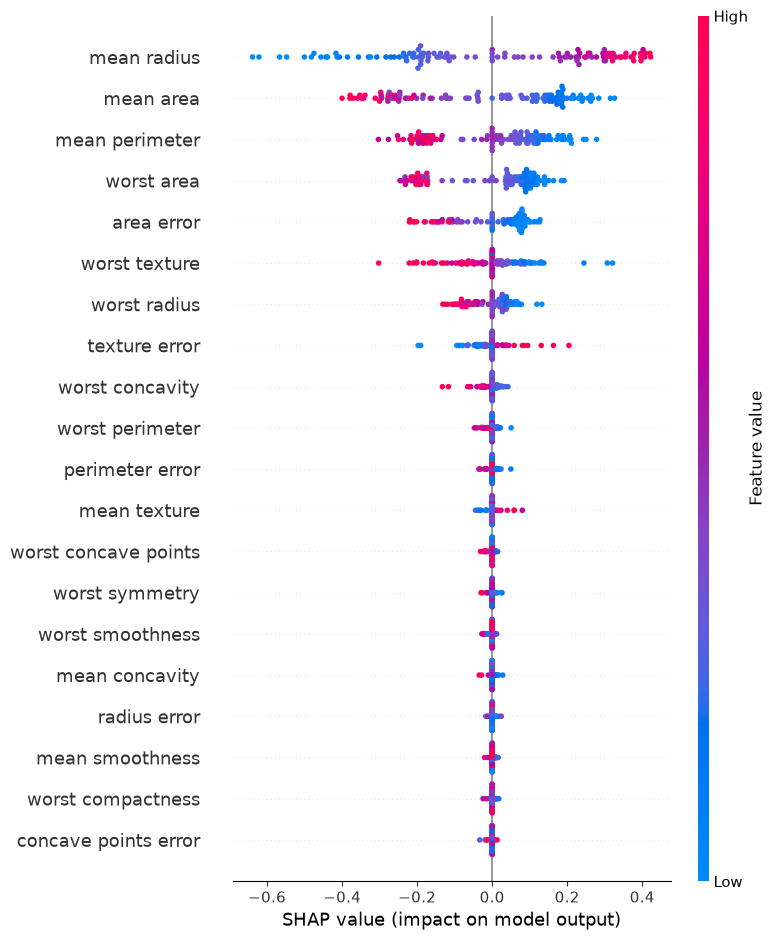

In [ ]:
shap.summary_plot(shap_values,x_test,feature_names=data['feature_names'])
# mostra quais features mais influenciam na predição do modelo
# o eixo x mostra o quando as  features influenciaram o modelo em sua previsão
# e no eixo y estao ordenados as features com mais peso para a rede

In [ ]:
shap.initjs()
shap.force_plot(explainer.expected_value,shap_values[2],x_test[3],feature_names=data["feature_names"])
# pega a media das predicoes e ve o quando cada feature influenciou para o resultado

In [ ]:
mean_abs_shap_values = np.abs(shap_values).mean(axis=0)
# pegando o valor absoluto da influencia de cada feature para o modelo

In [16]:
feature_names = data["feature_names"]

In [17]:
feature_importance = zip(feature_names,mean_abs_shap_values)

In [18]:
sorted_features_importances=sorted(feature_importance,key=lambda x: x[1], reverse=True)

In [19]:
for feature,importance in sorted_features_importances:
    print(feature, ": ",importance)

mean radius :  0.257718068026313
mean area :  0.1902494297212862
mean perimeter :  0.12705426928934976
worst area :  0.11799153390979869
area error :  0.0815977088628281
worst texture :  0.0648899896039618
worst radius :  0.04412174857144276
texture error :  0.025591195660173344
worst concavity :  0.01305861445623725
worst perimeter :  0.0071996563685886115
perimeter error :  0.00483831805516837
mean texture :  0.0046992107517108425
worst concave points :  0.003261427669818093
worst symmetry :  0.0021863691453116833
worst smoothness :  0.0019442397463998488
mean concavity :  0.0016841383283763105
radius error :  0.0013408639570905998
mean smoothness :  0.0011752171075565922
worst compactness :  0.0011171195397750536
concave points error :  0.0009250237288993106
mean compactness :  0.0009044099939267477
symmetry error :  0.0008423776739602088
worst fractal dimension :  0.0008363975863675011
mean symmetry :  0.0008115203599200195
smoothness error :  0.0007711482271169899
fractal dimensio